In [9]:
# core imports needed for this stage
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [10]:
df = pd.read_csv('../datasets/mail_spam_classification/emails.csv')
target_col = "Prediction"

print("Shape of dataset:", df.shape)
print("Class distribution:\n", df[target_col].value_counts())

id_cols = [c for c in df.columns if df[c].dtype == "object"]
print("Dropping non-numeric columns:", id_cols)

X = df.drop(columns=[target_col] + id_cols)
y = df[target_col]

print("Final feature matrix shape:", X.shape)

Shape of dataset: (5172, 3002)
Class distribution:
 Prediction
0    3672
1    1500
Name: count, dtype: int64
Dropping non-numeric columns: ['Email No.']
Final feature matrix shape: (5172, 3000)


BASIC EDA REPORT

Shape of dataset: 5172 rows, 3002 columns

Data types:
int64     3001
object       1
Name: count, dtype: int64

No missing values found.

Duplicate rows: 0

Class distribution (Prediction):
Prediction
0    3672
1    1500
Name: count, dtype: int64
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64 %


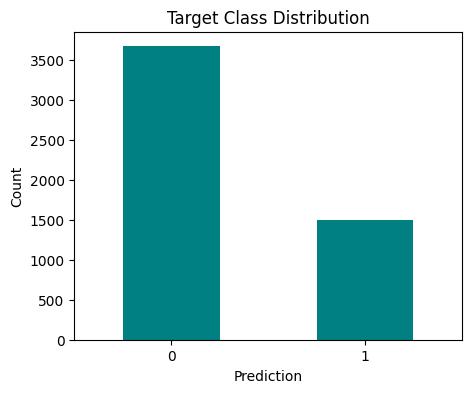

In [23]:
target_col = "Prediction"

print("=" * 50)
print("BASIC EDA REPORT")
print("=" * 50)

#Shape
print(f"\nShape of dataset: {df.shape[0]} rows, {df.shape[1]} columns")

#Data types
print("\nData types:")
print(df.dtypes.value_counts())

#Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("\nNo missing values found.")
else:
    print("\nMissing values per column:")
    print(missing)

#Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")


print(f"\nClass distribution ({target_col}):")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True).round(3) * 100, "%")

plt.figure(figsize=(5, 4))
df[target_col].value_counts().plot(kind="bar", color="teal")
plt.title("Target Class Distribution")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [11]:
### Step 4: Split the dataset into training and testing sets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape :", X_test_scaled.shape)

Training set shape: (4137, 3000)
Testing set shape : (1035, 3000)


### Step 5: Train baseline Logistic Regression

In [13]:
start = time.time()
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg_train_time = time.time() - start

y_pred_log = log_reg.predict(X_test_scaled)

log_reg_baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1 Score": f1_score(y_test, y_pred_log),
    "Training Time": log_reg_train_time
}

print("Baseline Logistic Regression Performance")
for k, v in log_reg_baseline_metrics.items():
    print(f"{k}: {v:.4f}")

Baseline Logistic Regression Performance
Accuracy: 0.9671
Precision: 0.9236
Recall: 0.9667
F1 Score: 0.9446
Training Time: 2.3089


### Step 6: Tune Logistic Regression hyperparameters

In [14]:
log_reg_param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear"]   # dropped saga - liblinear supports both l1 and l2, and is much faster on this wide dataset
}

log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    log_reg_param_grid,
    cv=3,          # reduced from 5 to 3 folds to cut down total fits
    scoring="accuracy",
    n_jobs=2,
    verbose=2      # shows progress so you can see it's actually running
)

start = time.time()
log_reg_grid.fit(X_train_scaled, y_train)
log_reg_tuning_time = time.time() - start

print("Best Logistic Regression Parameters:", log_reg_grid.best_params_)
print("Best CV Accuracy:", round(log_reg_grid.best_score_, 4))
print("Tuning Time:", round(log_reg_tuning_time, 4), "seconds")

best_log_reg = log_reg_grid.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Logistic Regression Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.9633
Tuning Time: 119.8706 seconds


### Step 7: Train SVM with different kernels

In [15]:
svm_kernels = ["linear", "poly", "rbf", "sigmoid"]
svm_kernel_results = []

for kernel in svm_kernels:
    start = time.time()
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    y_pred_svm = svm_model.predict(X_test_scaled)

    svm_kernel_results.append({
        "Kernel": kernel,
        "Accuracy": round(accuracy_score(y_test, y_pred_svm), 4),
        "F1 Score": round(f1_score(y_test, y_pred_svm), 4),
        "Training Time (s)": round(train_time, 4)
    })

svm_kernel_table = pd.DataFrame(svm_kernel_results)
svm_kernel_table

,Kernel,Accuracy,F1 Score,Training Time (s)
0,linear,0.9507,0.9151,7.4115
1,poly,0.7594,0.3064,37.0012
2,rbf,0.9304,0.8657,23.0811
3,sigmoid,0.8754,0.7650,15.8422


### Step 8: Tune SVM hyperparameters

In [16]:
svm_param_dist = {
    "kernel": ["linear", "rbf", "sigmoid"],   # dropped poly - by far the slowest on 3000 features
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"]
}

svm_random = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=svm_param_dist,
    n_iter=8,        # reduced from 20 - fewer combos to try
    cv=3,            # reduced from 5 folds
    scoring="accuracy",
    random_state=42,
    n_jobs=2,        # reduced from -1 to avoid overloading memory
    verbose=2        # shows progress per fit
)

start = time.time()
svm_random.fit(X_train_scaled, y_train)
svm_tuning_time = time.time() - start

print("Best SVM Parameters:", svm_random.best_params_)
print("Best CV Accuracy:", round(svm_random.best_score_, 4))
print("Tuning Time:", round(svm_tuning_time, 4), "seconds")

best_svm = svm_random.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best SVM Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best CV Accuracy: 0.9526
Tuning Time: 214.4701 seconds


### Step 9: Evaluate models using standard metrics

In [17]:
# Table: Hyperparameter Tuning Results
tuning_results_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Search Method": "Grid Search",
        "Best Parameters": log_reg_grid.best_params_,
        "Best CV Accuracy": round(log_reg_grid.best_score_, 4)
    },
    {
        "Model": "SVM",
        "Search Method": "Randomized Search",
        "Best Parameters": svm_random.best_params_,
        "Best CV Accuracy": round(svm_random.best_score_, 4)
    }
])
tuning_results_table

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",0.9633
1,SVM,Randomized Search,"{'kernel': 'rbf', 'gamma': 'scale', 'C': 10}",0.9526


In [18]:
# Table: Logistic Regression Performance (tuned model, refit on full training set)
start = time.time()
best_log_reg.fit(X_train_scaled, y_train)
final_log_reg_time = time.time() - start

y_pred_final_log = best_log_reg.predict(X_test_scaled)

log_reg_performance_table = pd.DataFrame([
    {"Metric": "Accuracy", "Value": round(accuracy_score(y_test, y_pred_final_log), 4)},
    {"Metric": "Precision", "Value": round(precision_score(y_test, y_pred_final_log), 4)},
    {"Metric": "Recall", "Value": round(recall_score(y_test, y_pred_final_log), 4)},
    {"Metric": "F1 Score", "Value": round(f1_score(y_test, y_pred_final_log), 4)},
    {"Metric": "Training Time (s)", "Value": round(final_log_reg_time, 4)}
])

print("Tuned Logistic Regression - Test Set Performance")
log_reg_performance_table

Tuned Logistic Regression - Test Set Performance


,Metric,Value
0,Accuracy,0.9691
1,Precision,0.9241
2,Recall,0.9733
3,F1 Score,0.9481
4,Training Time (s),4.0457


In [19]:
# Quick confusion-matrix check for both tuned models (useful for the report's Results section)
print("Confusion Matrix - Logistic Regression (tuned)")
print(confusion_matrix(y_test, y_pred_final_log))

start = time.time()
best_svm.fit(X_train_scaled, y_train)
final_svm_time = time.time() - start
y_pred_final_svm = best_svm.predict(X_test_scaled)

print("\nConfusion Matrix - SVM (tuned)")
print(confusion_matrix(y_test, y_pred_final_svm))

Confusion Matrix - Logistic Regression (tuned)
[[711  24]
 [  8 292]]

Confusion Matrix - SVM (tuned)
[[723  12]
 [ 33 267]]


### Step 10: 5-Fold Cross-Validation

In [22]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # reduced from 5 to 3

print("Running CV for Logistic Regression...")
log_reg_cv_scores = cross_val_score(
    best_log_reg, X_train_scaled, y_train,
    cv=cv_strategy, scoring="accuracy",
    n_jobs=2, verbose=2
)

print("Running CV for SVM...")
svm_cv_scores = cross_val_score(
    best_svm, X_train_scaled, y_train,
    cv=cv_strategy, scoring="accuracy",
    n_jobs=2, verbose=2
)

cv_results_table = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(3)] + ["Average"],
    "Logistic Regression": list(np.round(log_reg_cv_scores, 4)) + [round(log_reg_cv_scores.mean(), 4)],
    "SVM": list(np.round(svm_cv_scores, 4)) + [round(svm_cv_scores.mean(), 4)]
})

cv_results_table

Running CV for Logistic Regression...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:    3.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for SVM...


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   34.4s finished


,Fold,Logistic Regression,SVM
0,Fold 1,0.9637,0.9550
1,Fold 2,0.9616,0.9405
2,Fold 3,0.9550,0.9565
3,Average,0.9601,0.9507
